# 🤖 04 - Gözetimli Makine Öğrenmesi (Segment-Level Classification)
## Uydu Telemetri Anomali Tespiti

**Amaç:** Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest (Ensemble)
2. Support Vector Machine (SVM)
3. XGBoost (Gradient Boosting)
4. MLP (Deep Learning)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

import sys
sys.path.insert(0, '..')
from src.models.supervised import SupervisedAnomalyDetector

print('✅ Kütüphaneler ve Model Sınıfı Yüklendi.')

# Gelişmiş Modeller İçin Eklemeler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import json
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
MODEL_DIR = '../models'
METRICS_FILE = '../reports/metrics/adv_metrics.json'
import os
FIGURES_DIR = '../reports/figures'
METRICS_DIR = '../reports/metrics'


I0000 00:00:1780424890.647686  218851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780424890.958389  218851 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780424892.109937  218851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ Kütüphaneler ve Model Sınıfı Yüklendi.


---
## 📥 Bölüm 1: Veri Hazırlama


In [2]:
df_features = pd.read_parquet('../data/features/segment_features.parquet')
print(f"📊 Özellik Matrisi: {df_features.shape}")

drop_cols = ['segment', 'anomaly', 'train', 'channel']
feature_cols = [c for c in df_features.columns if c not in drop_cols]
X = df_features[feature_cols].fillna(0)
y = df_features['anomaly']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_sm)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train (SMOTE): {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")


📊 Özellik Matrisi: (2123, 28)
Train (SMOTE): (2296, 24), Val: (255, 24), Test: (425, 24)


---
## 🌲 Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


🌲 Random Forest eğitiliyor...
🚀 XGBoost eğitiliyor...


---
## ⚔️ Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


⚔️ SVM (rbf kernel) eğitiliyor...


---
## 🧠 Bölüm 4: MLP (Derin Öğrenme)


🧠 MLP eğitiliyor...
Epoch 1/80


W0000 00:00:1780424894.057600  218851 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8410 - loss: 0.3570 - val_accuracy: 0.9373 - val_loss: 0.3771
Epoch 2/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9273 - loss: 0.1904 - val_accuracy: 0.9412 - val_loss: 0.2427
Epoch 3/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9434 - loss: 0.1435 - val_accuracy: 0.9608 - val_loss: 0.1514
Epoch 4/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9447 - loss: 0.1479 - val_accuracy: 0.9647 - val_loss: 0.1197
Epoch 5/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9582 - loss: 0.1108 - val_accuracy: 0.9647 - val_loss: 0.1062
Epoch 6/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9612 - loss: 0.1134 - val_accuracy: 0.9686 - val_loss: 0.0899
Epoch 7/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.1028 - val_accuracy: 0.9647 - val_loss: 0.0994
Epoch 8/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9634 - loss: 0.0993 - val_accuracy: 0.9647 - val_loss: 0.1038
Epo

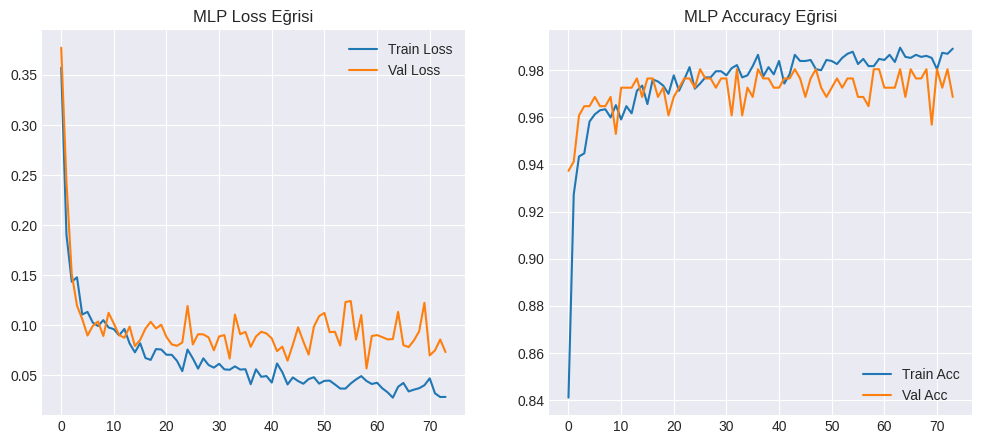

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## 📊 Bölüm 5: Değerlendirme


In [6]:
detector.evaluate_model('RandomForest', X_test_s, y_test)
detector.evaluate_model('XGBoost', X_test_s, y_test)
detector.evaluate_model('SVM', X_test_s, y_test)
detector.evaluate_model('MLP', X_test_s, y_test.values)

results_df = pd.DataFrame(detector.metrics).T
display(results_df.style.background_gradient(cmap='Blues'))


,Accuracy,Precision,Recall,F1_Score,AUC,FAR
RandomForest,0.938824,0.867470,0.827586,0.847059,0.983643,0.032544
XGBoost,0.952941,0.913580,0.850575,0.880952,0.982929,0.020710
SVM,0.943529,0.838710,0.896552,0.866667,0.980446,0.044379
MLP,0.952941,0.885057,0.885057,0.885057,0.984017,0.029586


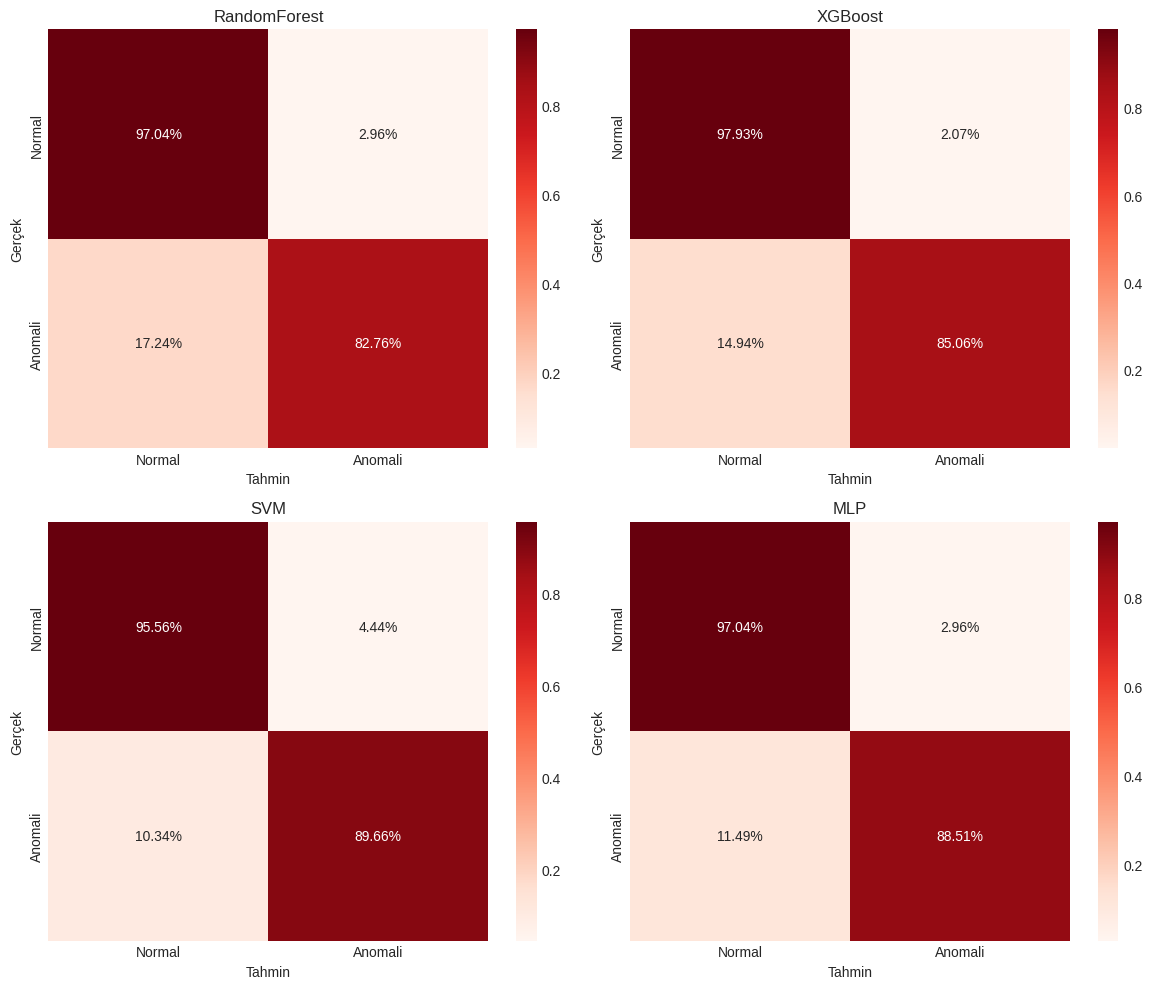

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(detector.models.keys()):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0)>=0.5).astype(int).flatten() if name=='MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()


---
## 🔍 Bölüm 6: ROC Eğrisi


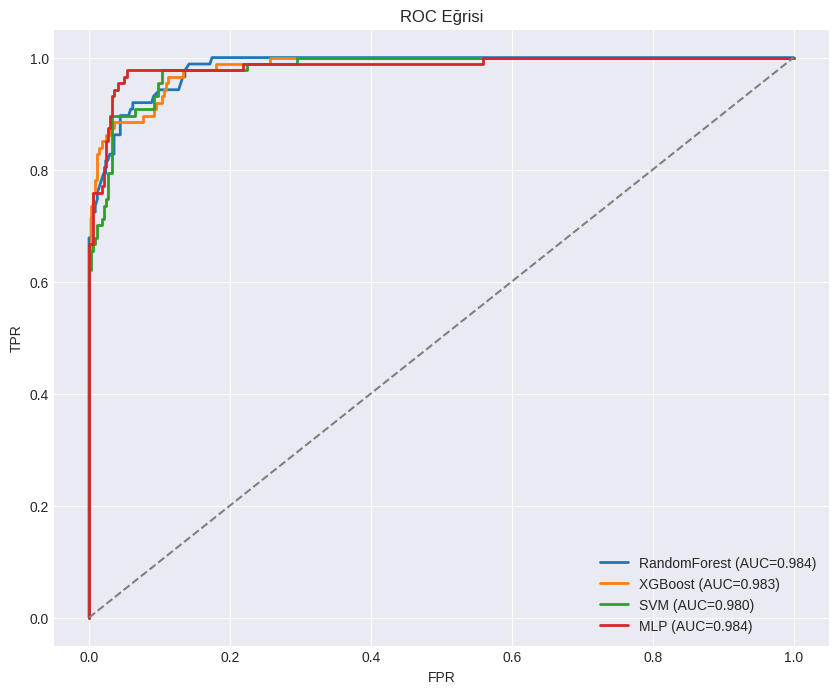

In [8]:
plt.figure(figsize=(10, 8))
for name, model in detector.models.items():
    yp = model.predict(X_test_s, verbose=0).flatten() if name=='MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr,tpr,_ = roc_curve(y_test, yp); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi'); plt.legend(loc='lower right')
plt.show()


---
## 💾 Bölüm 7: Kaydetme


In [9]:
import joblib
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump({'X_test': X_test_s, 'y_test': y_test.values, 'feature_cols': feature_cols}, '../models/test_data.joblib')
detector.save_model('RandomForest', '../models/rf_model.joblib')
detector.save_model('XGBoost', '../models/xgb_model.joblib')
detector.save_model('SVM', '../models/svm_model.joblib')
detector.save_model('MLP', '../models/mlp_model.keras')
detector.save_metadata('../reports/metrics/supervised_metrics.json')
print("✅ Tüm modeller ve scaler kaydedildi.")


✅ Model kaydedildi: ../models/rf_model.joblib
✅ Model kaydedildi: ../models/xgb_model.joblib
✅ Model kaydedildi: ../models/svm_model.joblib
✅ Model kaydedildi: ../models/mlp_model.keras
📝 Metadata kaydedildi: ../reports/metrics/supervised_metrics.json
✅ Tüm modeller ve scaler kaydedildi.


### HTML Rapor


In [10]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 04_model_supervised.ipynb --output ../reports/04_model_supervised_rapor.html



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] Converting notebook 04_model_supervised.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 889405 bytes to ../reports/04_model_supervised_rapor.html


## 5. Gelişmiş Modeller (LightGBM, CatBoost & Stacking)\nBu bölümde projenin performansını maksimize etmek için eklenen LightGBM, CatBoost ve Ensemble modelleri bulunmaktadır.

## 2. Model Tanımlamaları ve Eğitim

In [11]:
# LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)

# CatBoost
catb = CatBoostClassifier(iterations=300, learning_rate=0.05, random_state=42, verbose=0)

# Stacking Classifier (Meta Model)
# Using strong diverse base learners
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
]
# Meta-learner is LogisticRegression to blend them
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)

models = {
    "LightGBM": lgbm,
    "CatBoost": catb,
    "Stacking Ensemble": stacking
}

print("Eğitim başlıyor...")
trained_models = {}
for name, model in models.items():
    print(f"{name} eğitiliyor...")
    model.fit(X_train, y_train)
    trained_models[name] = model
print("Eğitim tamamlandı!")

Eğitim başlıyor...
LightGBM eğitiliyor...
CatBoost eğitiliyor...
Stacking Ensemble eğitiliyor...


[21:28:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[21:28:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[21:28:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Eğitim tamamlandı!


## 3. Performans Değerlendirme ve Modellerin Kaydedilmesi


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       338
           1       0.91      0.82      0.86        87

    accuracy                           0.95       425
   macro avg       0.93      0.90      0.91       425
weighted avg       0.94      0.95      0.94       425


--- CatBoost ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       338
           1       0.93      0.80      0.86        87

    accuracy                           0.95       425
   macro avg       0.94      0.89      0.92       425
weighted avg       0.95      0.95      0.95       425


--- Stacking Ensemble ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       338
           1       0.93      0.80      0.86        87

    accuracy                           0.95       425
   macro avg       0.94      0.89      0.92       425
weighted av

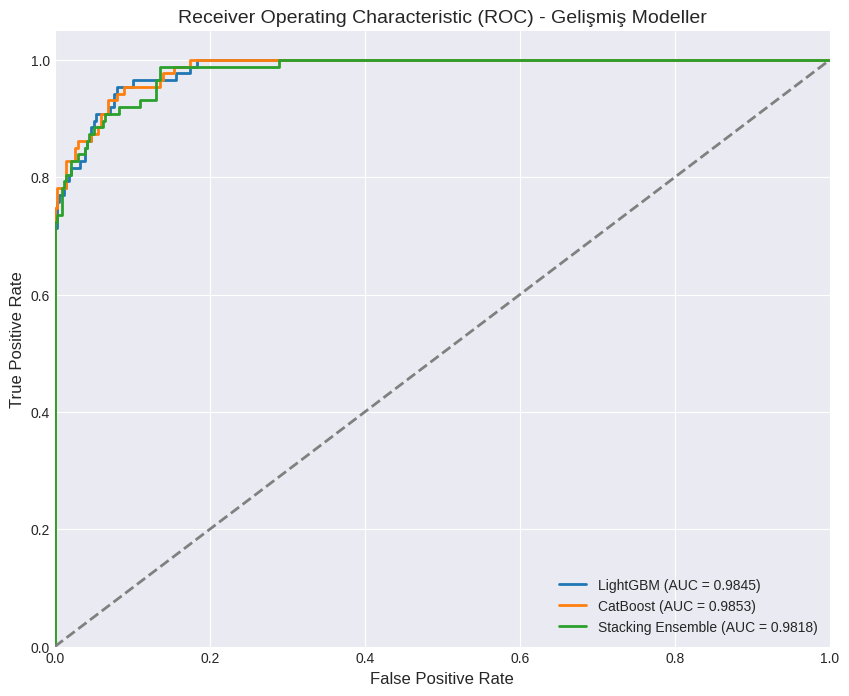

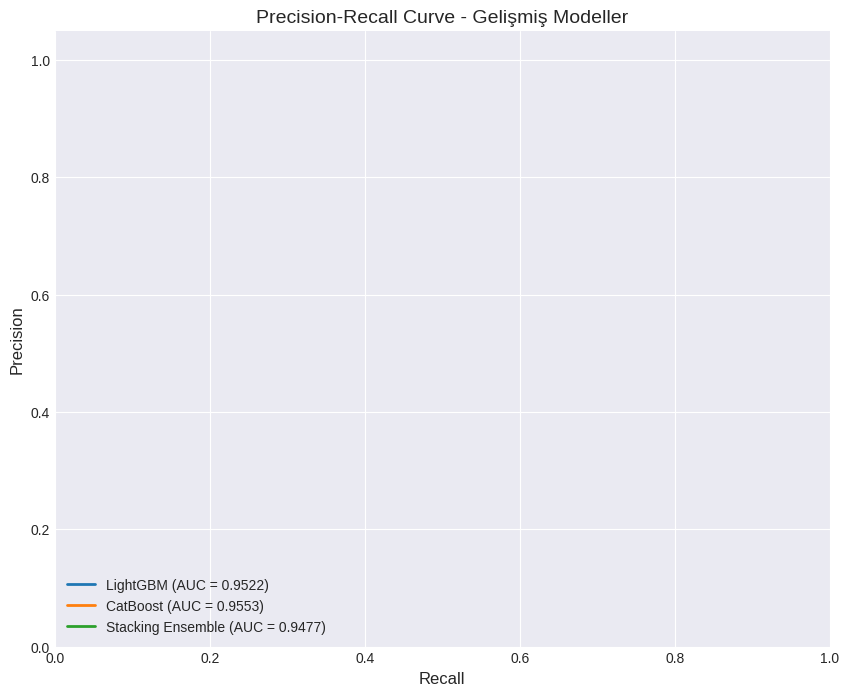

In [12]:
import time
metrics = {}
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    # Tahminler
    start_t = time.time()
    y_pred = model.predict(X_test)
    inf_time = (time.time() - start_t) * 1000 / len(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrik Hesaplamaları
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # from sklearn.metrics import precision_score, recall_score
    # we can compute precision and recall manually or use sklearn
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    recall = tp / (tp + fn) if (tp+fn) > 0 else 0
    
    metrics[name] = {
        "Accuracy": float(acc),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "AUC-ROC": float(roc_auc),
        "FAR": float(fp / (fp + tn)) if (fp + tn) > 0 else 0,
        "FNR": float(fn / (tp + fn)) if (tp + fn) > 0 else 0,
        "Inf.Time(ms)": float(inf_time)
    }
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    
    # Eğrileri Çizdir
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
    ax_pr.plot(recall, precision, lw=2, label=f"{name} (AUC = {pr_auc:.4f})")
    
    # Modeli Kaydet
    fname = name.lower().replace(" ", "_") + "_model.joblib"
    joblib.dump(model, os.path.join(MODEL_DIR, fname))

# ROC Eğrisi Finalize Et
ax_roc.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('Receiver Operating Characteristic (ROC) - Gelişmiş Modeller', fontsize=14)
ax_roc.legend(loc="lower right")
fig_roc.savefig(os.path.join(FIGURES_DIR, "adv_roc_curves.png"), dpi=300, bbox_inches='tight')

# PR Eğrisi Finalize Et
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title('Precision-Recall Curve - Gelişmiş Modeller', fontsize=14)
ax_pr.legend(loc="lower left")
fig_pr.savefig(os.path.join(FIGURES_DIR, "adv_pr_curves.png"), dpi=300, bbox_inches='tight')

# Metrikleri JSON'a kaydet (Arayüzde okumak için)
with open(os.path.join(METRICS_DIR, "adv_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
    
print("Tüm model dosyaları ve metrikler başarıyla kaydedildi.")

## 4. Feature Importance Karşılaştırması

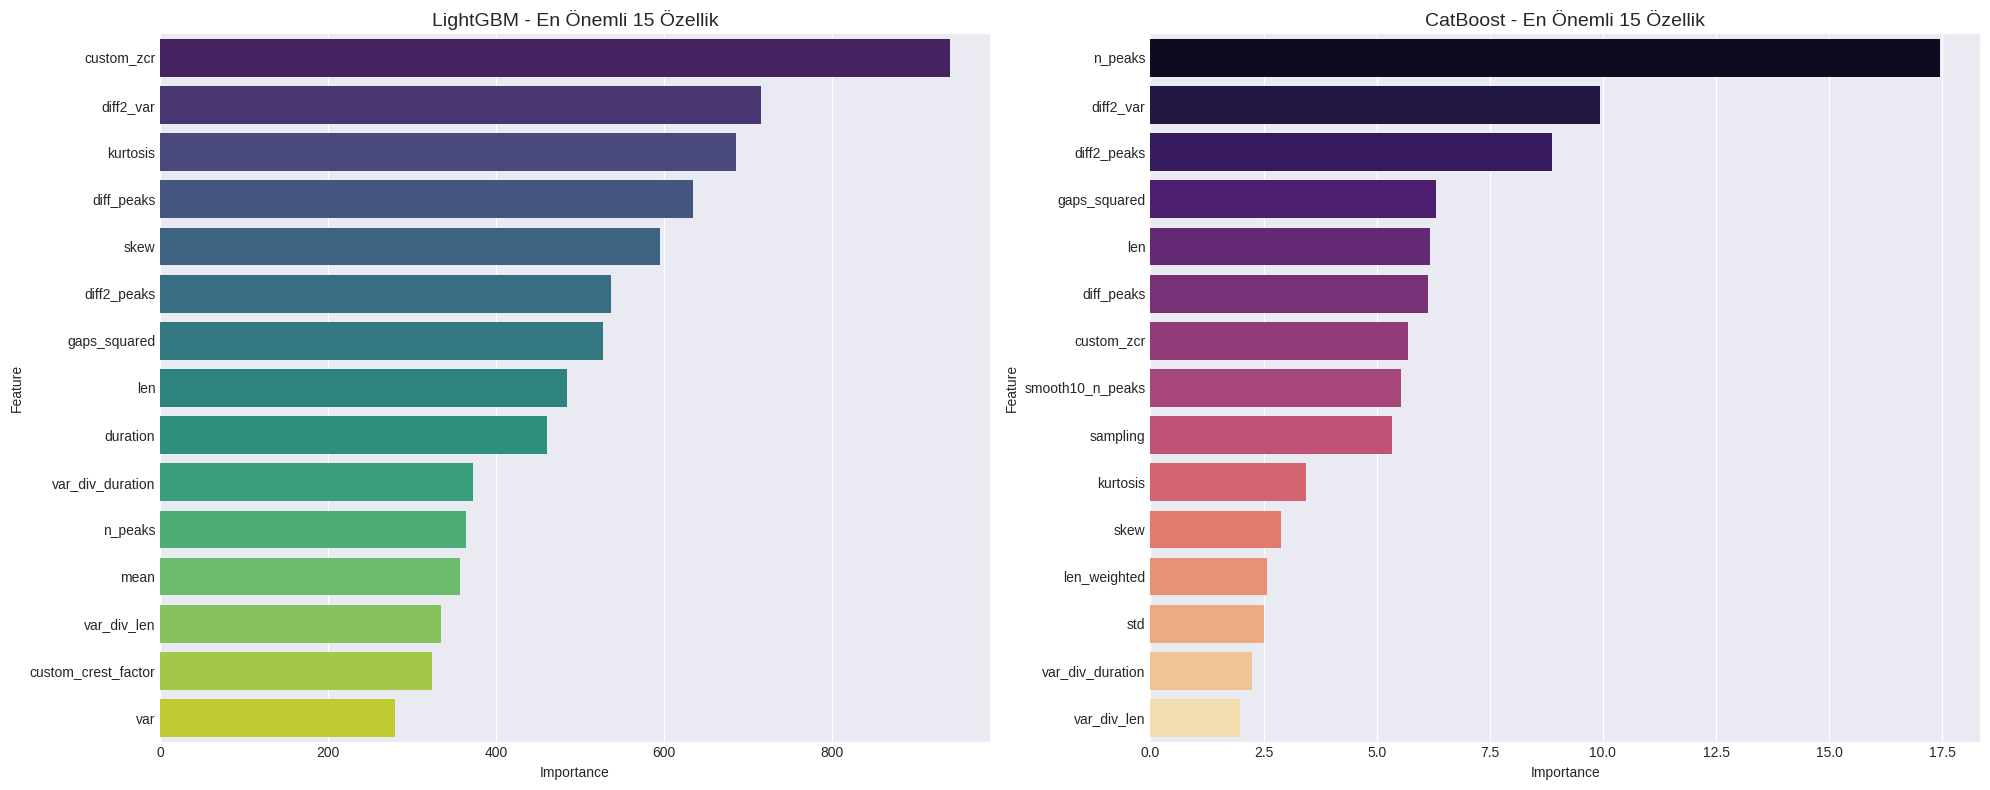

In [13]:
# LightGBM ve CatBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LGBM
lgbm_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['LightGBM'].feature_importances_})
lgbm_imp = lgbm_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=lgbm_imp, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM - En Önemli 15 Özellik', fontsize=14)

# CatBoost
catb_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['CatBoost'].get_feature_importance()})
catb_imp = catb_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=catb_imp, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost - En Önemli 15 Özellik', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "adv_feature_importance.png"), dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Genişletilmiş Modeller (Klasik ML + Derin Sıralı Ağlar)

Model havuzunu zenginleştirmek için **29 yeni gözetimli model** eklenmiştir:

**Klasik ML (14):** Extra Trees, Gradient Boosting, HistGradientBoosting, AdaBoost, KNN, Logistic Regression, Decision Tree, Gaussian Naive Bayes, Voting Ensemble, LDA, QDA, Bagging, Ridge, SGD

**Derin sıralı / hibrit ağlar (15):** LSTM, BiLSTM, GRU, BiGRU, 1D-CNN, CNN-LSTM, **CNN-BiLSTM**, **CNN-GRU**, Transformer, TCN, Attention-BiLSTM, **FCN**, **ResNet-1D**, **InceptionTime**, **LSTM-FCN**.

> Sıralı modeller tablo özelliklerini `(örnek, özellik, 1)` biçiminde 3B tensöre dönüştürerek işler; bu dönüşüm `SupervisedAnomalyDetector` içinde otomatik yapılır. FCN, ResNet-1D, InceptionTime ve LSTM-FCN, UCR benchmark'ında öne çıkan SOTA zaman serisi sınıflandırma mimarileridir. Tüm modeller Bölüm 1'deki aynı ölçeklenmiş (`X_*_s`) ve SMOTE ile dengelenmiş eğitim verisini kullanır.

In [14]:
# --- 6.1 Klasik ML Genişletme (14 model) ---
# Tutarlılık için Bölüm 2-4 ile aynı ölçeklenmiş + SMOTE'lu eğitim verisi kullanılır.
ext_detector = SupervisedAnomalyDetector(random_state=42)
ext_detector.train_extra_trees(X_train_s, y_train_sm)
ext_detector.train_gradient_boosting(X_train_s, y_train_sm)
ext_detector.train_hist_gradient_boosting(X_train_s, y_train_sm)
ext_detector.train_adaboost(X_train_s, y_train_sm)
ext_detector.train_knn(X_train_s, y_train_sm)
ext_detector.train_logistic_regression(X_train_s, y_train_sm)
ext_detector.train_decision_tree(X_train_s, y_train_sm)
ext_detector.train_naive_bayes(X_train_s, y_train_sm)
ext_detector.train_voting(X_train_s, y_train_sm)
ext_detector.train_lda(X_train_s, y_train_sm)
ext_detector.train_qda(X_train_s, y_train_sm)
ext_detector.train_bagging(X_train_s, y_train_sm)
ext_detector.train_ridge(X_train_s, y_train_sm)
ext_detector.train_sgd(X_train_s, y_train_sm)

classic_files = {
    'ExtraTrees':           'extratrees_model.joblib',
    'GradientBoosting':     'gradientboosting_model.joblib',
    'HistGradientBoosting': 'histgradientboosting_model.joblib',
    'AdaBoost':             'adaboost_model.joblib',
    'KNN':                  'knn_model.joblib',
    'LogisticRegression':   'logisticregression_model.joblib',
    'DecisionTree':         'decisiontree_model.joblib',
    'NaiveBayes':           'naivebayes_model.joblib',
    'Voting Ensemble':      'voting_ensemble_model.joblib',
    'LDA':                  'lda_model.joblib',
    'QDA':                  'qda_model.joblib',
    'Bagging':              'bagging_model.joblib',
    'Ridge':                'ridge_model.joblib',
    'SGD':                  'sgd_model.joblib',
}
for name, fname in classic_files.items():
    ext_detector.evaluate_model(name, X_test_s, y_test)
    ext_detector.save_model(name, os.path.join(MODEL_DIR, fname))

print('\n✅ Klasik ML modelleri eğitildi ve kaydedildi.')
display(pd.DataFrame({k: ext_detector.metrics[k] for k in classic_files}).T.style.background_gradient(cmap='Greens'))

🌳 Extra Trees eğitiliyor...
📈 Gradient Boosting eğitiliyor...
⚡ HistGradientBoosting eğitiliyor...
⚡ AdaBoost eğitiliyor...
👥 KNN (k=15) eğitiliyor...
📉 Logistic Regression eğitiliyor...
🌿 Decision Tree eğitiliyor...
🎲 Gaussian Naive Bayes eğitiliyor...
🗳️ Voting Ensemble (soft) eğitiliyor...
📏 LDA (Linear Discriminant Analysis) eğitiliyor...
📐 QDA (Quadratic Discriminant Analysis) eğitiliyor...
🧺 Bagging eğitiliyor...
🪜 Ridge Classifier eğitiliyor...
🛷 SGD Classifier (log-loss) eğitiliyor...
✅ Model kaydedildi: ../models/extratrees_model.joblib
✅ Model kaydedildi: ../models/gradientboosting_model.joblib
✅ Model kaydedildi: ../models/histgradientboosting_model.joblib
✅ Model kaydedildi: ../models/adaboost_model.joblib
✅ Model kaydedildi: ../models/knn_model.joblib
✅ Model kaydedildi: ../models/logisticregression_model.joblib
✅ Model kaydedildi: ../models/decisiontree_model.joblib
✅ Model kaydedildi: ../models/naivebayes_model.joblib
✅ Model kaydedildi: ../models/voting_ensemble_model.j

,Accuracy,Precision,Recall,F1_Score,AUC,FAR
ExtraTrees,0.945882,0.900000,0.827586,0.862275,0.988064,0.023669
GradientBoosting,0.938824,0.850575,0.850575,0.850575,0.980956,0.038462
HistGradientBoosting,0.950588,0.923077,0.827586,0.872727,0.989322,0.017751
AdaBoost,0.934118,0.831461,0.850575,0.840909,0.966197,0.044379
KNN,0.931765,0.837209,0.827586,0.832370,0.954363,0.041420
LogisticRegression,0.917647,0.770833,0.850575,0.808743,0.961164,0.065089
DecisionTree,0.910588,0.747475,0.850575,0.795699,0.914728,0.073964
NaiveBayes,0.901176,0.857143,0.620690,0.720000,0.901041,0.026627
Voting Ensemble,0.948235,0.865169,0.885057,0.875000,0.984629,0.035503
LDA,0.882353,0.694737,0.758621,0.725275,0.928858,0.085799


In [15]:
# --- 6.2 Derin Sıralı / Hibrit Ağlar (15 model) ---
# LSTM, BiLSTM, GRU, BiGRU, 1D-CNN, CNN-LSTM, CNN-BiLSTM, CNN-GRU, Transformer, TCN,
# Attention-BiLSTM, FCN, ResNet-1D, InceptionTime, LSTM-FCN
y_train_arr = y_train_sm.values if hasattr(y_train_sm, 'values') else y_train_sm
y_val_arr   = y_val.values if hasattr(y_val, 'values') else y_val
y_test_arr  = y_test.values if hasattr(y_test, 'values') else y_test

seq_trainers = {
    'LSTM':             ext_detector.train_lstm,
    'BiLSTM':           ext_detector.train_bilstm,
    'GRU':              ext_detector.train_gru,
    'BiGRU':            ext_detector.train_bigru,
    'CNN1D':            ext_detector.train_cnn1d,
    'CNN_LSTM':         ext_detector.train_cnn_lstm,
    'CNN_BiLSTM':       ext_detector.train_cnn_bilstm,
    'CNN_GRU':          ext_detector.train_cnn_gru,
    'Transformer':      ext_detector.train_transformer,
    'TCN':              ext_detector.train_tcn,
    'Attention_BiLSTM': ext_detector.train_attention_bilstm,
    'FCN':              ext_detector.train_fcn,
    'ResNet1D':         ext_detector.train_resnet1d,
    'InceptionTime':    ext_detector.train_inceptiontime,
    'LSTM_FCN':         ext_detector.train_lstm_fcn,
}
seq_files = {
    'LSTM': 'lstm_model.keras', 'BiLSTM': 'bilstm_model.keras', 'GRU': 'gru_model.keras',
    'BiGRU': 'bigru_model.keras', 'CNN1D': 'cnn1d_model.keras', 'CNN_LSTM': 'cnn_lstm_model.keras',
    'CNN_BiLSTM': 'cnn_bilstm_model.keras', 'CNN_GRU': 'cnn_gru_model.keras',
    'Transformer': 'transformer_model.keras', 'TCN': 'tcn_model.keras',
    'Attention_BiLSTM': 'attention_bilstm_model.keras', 'FCN': 'fcn_model.keras',
    'ResNet1D': 'resnet1d_model.keras', 'InceptionTime': 'inceptiontime_model.keras',
    'LSTM_FCN': 'lstm_fcn_model.keras',
}

for name, trainer in seq_trainers.items():
    trainer(X_train_s, y_train_arr, X_val_s, y_val_arr, epochs=40, batch_size=32)
    ext_detector.evaluate_model(name, X_test_s, y_test_arr)
    ext_detector.save_model(name, os.path.join(MODEL_DIR, seq_files[name]))

print('\n✅ Derin sıralı modeller eğitildi ve kaydedildi.')
display(pd.DataFrame({k: ext_detector.metrics[k] for k in seq_files}).T.style.background_gradient(cmap='Purples'))

⏳ LSTM eğitiliyor...
Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5923 - loss: 0.6736 - val_accuracy: 0.7490 - val_loss: 0.6119
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6646 - loss: 0.6205 - val_accuracy: 0.8000 - val_loss: 0.5714
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7287 - loss: 0.5308 - val_accuracy: 0.8431 - val_loss: 0.4929
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8166 - loss: 0.4143 - val_accuracy: 0.8706 - val_loss: 0.3460
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8950 - loss: 0.2843 - val_accuracy: 0.8941 - val_loss: 0.2537
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8990 - loss: 0.2727 - val_accuracy: 0.9333 - val_loss: 0.2164
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9077 - loss: 0.2612 - val_accuracy: 0.9490 - val_loss: 0.2104
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9120 - loss: 0.2509 - val_accur

,Accuracy,Precision,Recall,F1_Score,AUC,FAR
LSTM,0.927059,0.785714,0.885057,0.832432,0.953581,0.062130
BiLSTM,0.938824,0.821053,0.896552,0.857143,0.968170,0.050296
GRU,0.936471,0.848837,0.839080,0.843931,0.970244,0.038462
BiGRU,0.950588,0.843750,0.931034,0.885246,0.989594,0.044379
CNN1D,0.948235,0.911392,0.827586,0.867470,0.982044,0.020710
CNN_LSTM,0.943529,0.879518,0.839080,0.858824,0.968442,0.029586
CNN_BiLSTM,0.936471,0.826087,0.873563,0.849162,0.986023,0.047337
CNN_GRU,0.950588,0.875000,0.885057,0.880000,0.976603,0.032544
Transformer,0.811765,0.533981,0.632184,0.578947,0.822519,0.142012
TCN,0.943529,0.909091,0.804598,0.853659,0.984255,0.020710
